<a href="https://colab.research.google.com/github/arman-hossain45/Artificial_Neural_Network_Project/blob/main/mini_project_FMnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# here do a mini project about fashion mnist data set and build a project

Here basically use image data set and convert the image in the
tabular data set and see the overall accuracy

In [4]:
import pandas as pd

from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [5]:
torch.manual_seed(42)

In [6]:
#dataset
df=pd.read_csv('fmnist_small.csv')
df.head(5)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [7]:
# index shoho name dibe

f = ['a','b','c']

for index,name in enumerate(f):
    print(index,name)

0 a
1 b
2 c


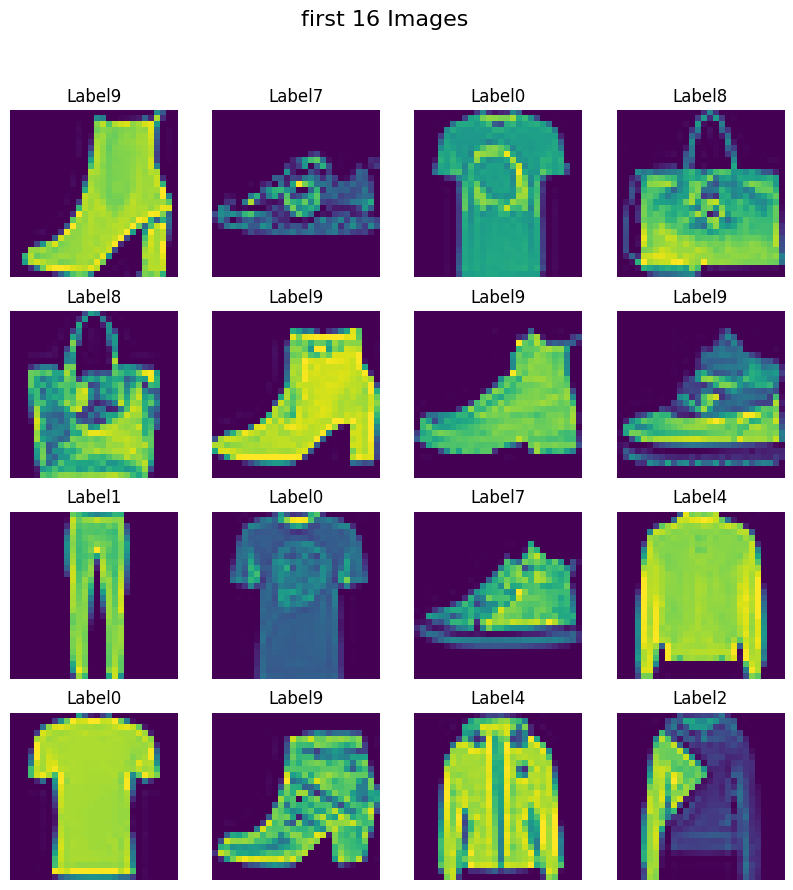

In [8]:
# basic grap
fig , axes = plt.subplots(4,4,figsize=(10,10))
fig.suptitle("first 16 Images",fontsize=16)

for i,ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)#1st col bade sob col nibe nd reshape ore dibe 28*28 a

  ax.imshow(img)
  ax.axis('off')

  ax.set_title(f'Label{df.iloc[i,0]}')



In [9]:
len(df.columns)

785

In [10]:
len(df.iloc[:,1:])

6000

In [11]:
#Train test split

x = df.iloc[:,1:].values# 1 no column or 0  no index nibe na baki gula nibe as a input
y = df.iloc[:,0].values# shudu 0 no index ta nibe baki gula nibe na

In [12]:
y.shape#shudu label target column nibe

(6000,)

In [13]:
x.shape# input column and target column nibe also

(6000, 784)

In [14]:
# train test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [15]:
# range all this data in a range with 255

x_train = x_train/255

x_test = x_test/255

# Custom data set


In [16]:
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features = torch.tensor(features,dtype=torch.float32)# data converssion

    self.labels = torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,idx):
    x = self.features[idx]
    y = self.labels[idx] # Corrected: Only get the label for the current index
    return x, y # Added return statement

# train and test data set create

In [17]:
train_dataset = CustomDataset(x_train,y_train)
test_dataset = CustomDataset(x_test,y_test)
len(train_dataset),len(test_dataset)

(4800, 1200)

# Data loader create

In [18]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

# define NN module

In [19]:
class MyNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()

    self.model =nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)# output softmax auto matic niye ney aikhan a
        #by default softmax apply kore multiclass classification ar jonno by default

    )

  def forward(self,x):
    return self.model(x)

# intariate model

In [20]:
epochs = 10
learning_rate = 0.1

In [21]:
model = MyNN(x_train.shape[1])

#Loss function

criterion = nn.CrossEntropyLoss()

#Opitimizer

optimizer = optim.SGD(model.parameters(),lr=learning_rate)

# trainnig loop



In [22]:
for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features,batch_labels in train_loader:

    #forward pass
    output = model(batch_features)

    #calculate loss
    loss = criterion(output,batch_labels)

    #back pass
    optimizer.zero_grad()
    loss.backward()

    #update
    optimizer.step()

    # print(loss.item())
    total_epoch_loss = total_epoch_loss + loss.item()


avg_loss = total_epoch_loss / len(train_loader)

print(avg_loss)

0.39840924287835755


In [23]:
for epoch in range(epochs):
  totall_epoch_loss = 0
  for batch_features,batch_label in train_loader:
    #forward pass
    output=model(batch_features)

    #calculate loss
    loss=criterion(output,batch_label)

    #back pass
    optimizer.zero_grad()
    loss.backward()

    #upgrade
    optimizer.step()



    totall_epoch_loss = totall_epoch_loss + loss.item()

avg_loss =totall_epoch_loss/len(train_loader)

print(avg_loss)




0.2620930323501428


In [25]:
temp = torch.tensor([
                    [0.2,0.1,0.7],
                    [0.2,0.1,0.7]
                    ])

_,predicted = torch.max(temp,1)
print(_)
print(predicted)

tensor([0.7000, 0.7000])
tensor([2, 2])


In [24]:
model.eval()

total = 0
correct = 0


with torch.no_grad():
  for batch_features,batch_labels in test_loader:
    outputs = model(batch_features)
    # print(f" outputs {outputs}")
    _,predicted = torch.max(outputs,1)
    # print(f"predicted {predicted}")

    #total
    total = total + batch_labels.shape[0]

    correct = correct + (predicted==batch_labels).sum().item()


print(correct/total)
# print(f"total number {total}")
# print(f"correct {correct}")

0.7891666666666667
